# Exploratory Data Analysis

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np   

sns.set_theme(style="whitegrid", context="talk")

project_dir = Path("..").resolve()
data_path = project_dir / "data" / "clean" / "master_dataset.csv"
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)


In [3]:
df = pd.read_csv(data_path)

df.head()

,Date,State,GDP ($ million),Unemployment rate (%),Housing Supply,International Student Enrolments,Population,Rental
0,2019-Q1,NSW,602960,5.0,3191.0,240549.0,8032991.0,482.0
1,2019-Q1,VIC,602960,5.0,2662.0,210652.0,6518716.0,388.0
2,2019-Q2,NSW,604702,5.2,3207.0,30419.0,8046748.0,482.0
3,2019-Q2,VIC,604702,5.2,2677.0,20494.0,6537305.0,388.0
4,2019-Q3,NSW,608205,5.3,3221.0,62728.0,8071350.0,480.0


## 1. Data Overview

### 1.1 Checking Data Types

In [5]:
df.dtypes

Date                                    str
State                                   str
GDP ($ million)                       int64
Unemployment rate (%)               float64
Housing Supply                      float64
International Student Enrolments    float64
Population                          float64
Rental                              float64
dtype: object

### 1.2 Fixing Date Type

In [6]:
df["Quarter"] = pd.PeriodIndex(df["Date"], freq="Q")
df = df.sort_values(["State", "Quarter"]).reset_index(drop=True)

df[["Date", "Quarter", "State"]].head()

,Date,Quarter,State
0,2019-Q1,2019Q1,NSW
1,2019-Q2,2019Q2,NSW
2,2019-Q3,2019Q3,NSW
3,2019-Q4,2019Q4,NSW
4,2020-Q1,2020Q1,NSW


## 2. Descriptive Analysis

### 2.1 Descriptive Statistics

In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,48,NaN,NaN,NaN,2021-11-15 10:00:00,2019-01-01 00:00:00,2020-06-08 06:00:00,2021-11-16 00:00:00,2023-04-23 18:00:00,2024-10-01 00:00:00,NaN
State,48,2,NSW,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GDP ($ million),48.0,NaN,NaN,NaN,636772.083333,569302.0,610245.0,642134.0,666597.5,676456.0,31074.339692
Unemployment rate (%),48.0,NaN,NaN,NaN,4.7,3.5,3.875,4.4,5.2,7.0,1.082157
Housing Supply,48.0,NaN,NaN,NaN,3083.375,2662.0,2824.5,3079.5,3359.25,3484.0,283.208714
International Student Enrolments,48.0,NaN,NaN,NaN,77166.708333,10941.0,24225.25,31672.0,90101.0,280011.0,82306.578881
Population,48.0,NaN,NaN,NaN,7457177.25,6518716.0,6615185.5,7519493.5,8126093.5,8536892.0,794035.653988
Rental,48.0,NaN,NaN,NaN,465.479167,380.0,392.25,470.0,493.25,647.0,71.915728


Rental prices average approximately 465 per week, with values ranging from 380 to 647. The relatively large standard deviation (71.92) indicates noticeable variation in rental prices across states and over time, particularly during the post-pandemic rental increase. International student enrolments display substantial variability, with a mean of around 77,167 students and values ranging from 10,941 to 280,011. The large standard deviation (82,307) reflects strong seasonal fluctuations and the significant disruptions caused by COVID-19 border closures and the later recovery period. Housing supply and population show relatively steady upward patterns over time. Housing supply averages approximately 3,083 dwellings, while population averages around 7.46 million. Compared to student enrolments, these variables exhibit more stable distributions and less extreme short-term fluctuations. GDP averages approximately $636.8 billion and generally remains stable throughout the sample, while unemployment rate averages 4.7%, ranging from 3.5% to 7.0%. The higher unemployment observations likely correspond to the economic disruptions during the COVID-19 pandemic.

### 2.2 Skewness of Variables

In [8]:
df.skew(numeric_only=True)

GDP ($ million)                    -0.367889
Unemployment rate (%)               0.860474
Housing Supply                     -0.012824
International Student Enrolments    1.255141
Population                          0.013530
Rental                              0.789653
dtype: float64

Rental prices show a moderate positive skewness (0.790), suggesting that higher rental values occur more frequently in the later part of the sample, particularly during the post-COVID rental surge. Similarly, international student enrolments exhibit relatively strong positive skewness (1.255), reflecting periods of unusually high enrolment levels and large seasonal spikes. Unemployment rate also shows positive skewness (0.860), indicating that higher unemployment observations occurred during specific periods, particularly around the COVID-19 pandemic. In contrast, housing supply (-0.013) and population (0.014) are approximately symmetric, suggesting relatively stable and steadily increasing distributions over time. GDP displays a slight negative skewness (-0.368), indicating a small number of lower GDP observations relative to the overall distribution. Overall, the results suggest that several variables, particularly international student enrolments and rental prices, contain noticeable asymmetry and periods of unusually large values, consistent with the economic disruptions and recovery observed during the sample period.

### 2.3 Correlation Matrix

In [9]:
corr_matrix = df[[
    "Rental",
    "International Student Enrolments",
    "GDP ($ million)",
    "Unemployment rate (%)",
    "Housing Supply",
    "Population"
]].corr()

corr_matrix

,Rental,International Student Enrolments,GDP ($ million),Unemployment rate (%),Housing Supply,Population
Rental,1.000000,0.070879,0.514931,-0.368316,0.870575,0.854118
International Student Enrolments,0.070879,1.000000,0.022967,-0.081963,0.064654,0.098465
GDP ($ million),0.514931,0.022967,1.000000,-0.879523,0.293473,0.170536
Unemployment rate (%),-0.368316,-0.081963,-0.879523,1.000000,-0.224793,-0.124664
Housing Supply,0.870575,0.064654,0.293473,-0.224793,1.000000,0.985579
Population,0.854118,0.098465,0.170536,-0.124664,0.985579,1.000000


Rental prices are strongly positively correlated with both housing supply (0.871) and population (0.854). This suggests that states and periods with larger populations and greater housing stock also tend to have higher rental prices. However, these strong positive correlations may partly reflect common upward trends over time rather than direct causal relationships. Rental prices also show a moderate positive correlation with GDP (0.515), indicating that stronger economic conditions are generally associated with higher rents. In contrast, unemployment rate has a moderate negative correlation with rental prices (-0.368), suggesting that weaker labour market conditions tend to coincide with lower rental prices. Notably, international student enrolments have a very weak positive correlation with rental prices (0.071). This indicates little simple linear relationship between the two variables in the raw data, suggesting that international student numbers alone may not strongly explain rental price variation.
The matrix also reveals an extremely high correlation between housing supply and population (0.986), which may indicate potential multicollinearity if both variables are included simultaneously in regression models. This is expected since population growth and housing expansion often occur together over time.

## 3. Time Series Trend

### 3.1 Rental Prices Over Time

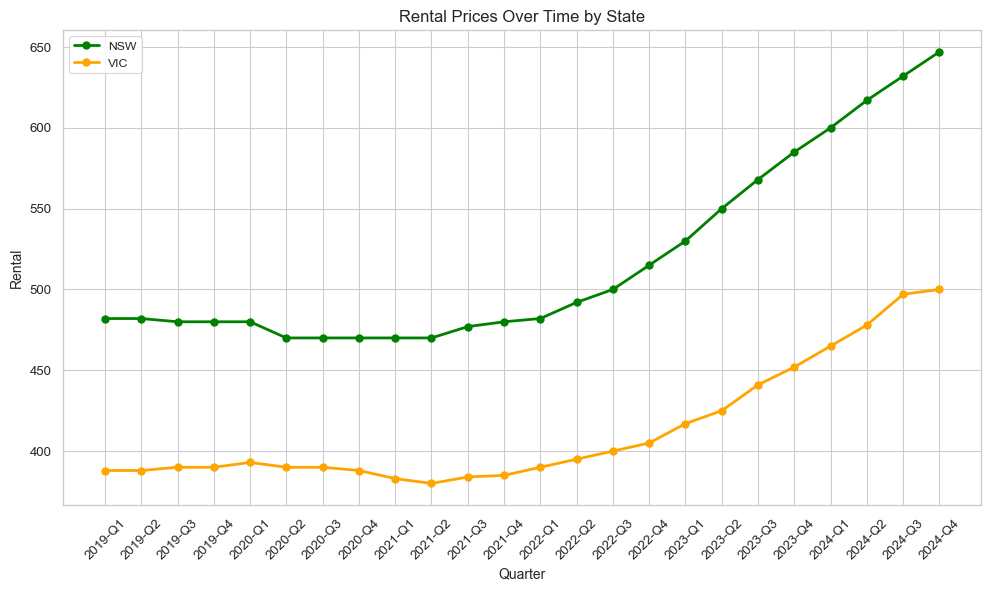

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

plt.figure(figsize=(10, 6))

palette = {"NSW": "green", "VIC": "orange"}

for state in df["State"].unique():
    temp = df[df["State"] == state]
    plt.plot(
        temp["Date"].astype(str),
        temp["Rental"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=state,
        color=palette.get(state)
    )

plt.xticks(rotation=45, fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.title("Rental Prices Over Time by State", fontsize=12)
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("Rental", fontsize=10)
plt.legend(title=None)
plt.tight_layout()
plt.savefig(output_dir / "01_rental_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Rental prices exhibit a clear upward trend over time in both New South Wales (NSW) and Victoria (VIC). Prices remain relatively stable between 2019 and early 2021, followed by a sustained increase from 2022 onwards. The rise is more pronounced in NSW, which consistently maintains higher rental levels than VIC throughout the period. Both states follow a broadly similar trajectory, suggesting that rental markets are influenced by common underlying factors. The sharp increase after 2022 may be consistent with rising housing demand or broader economic conditions affecting the rental market. However, the strong time trend observed in both series indicates that these patterns may be driven by shared macroeconomic forces over time, rather than reflecting a direct relationship between any single explanatory variable and rental prices.

### 3.2 International Students Over Time

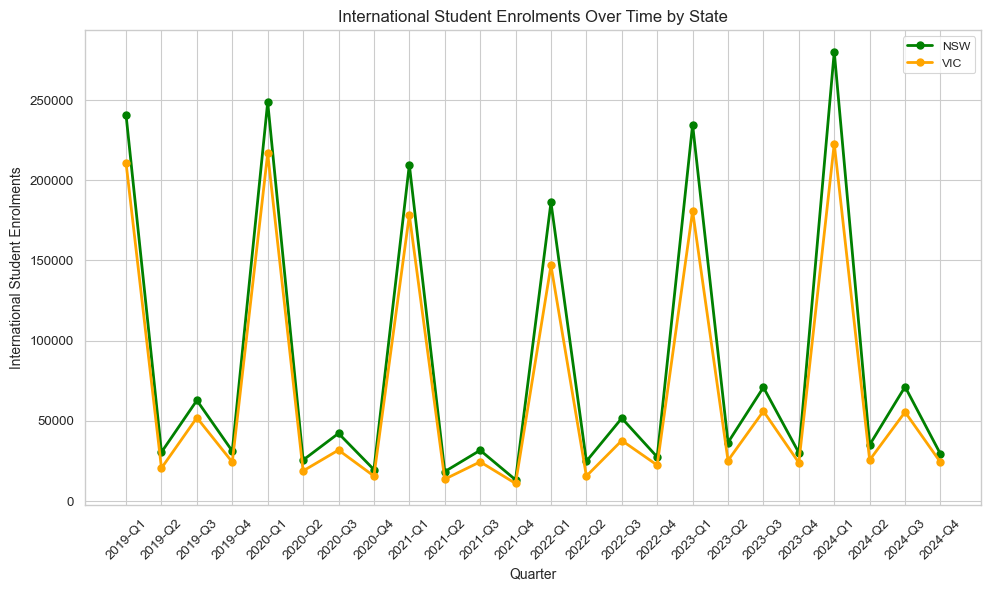

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

plt.figure(figsize=(10, 6))

palette = {"NSW": "green", "VIC": "orange"}

for state in df["State"].unique():
    temp = df[df["State"] == state]
    plt.plot(
        temp["Date"].astype(str),
        temp["International Student Enrolments"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=state,
        color=palette.get(state)
    )

plt.xticks(rotation=45, fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.title("International Student Enrolments Over Time by State", fontsize=12)
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("International Student Enrolments", fontsize=10)
plt.legend(title=None)
plt.tight_layout()
plt.savefig(output_dir / "02_student_trend.png", dpi=300, bbox_inches="tight")
plt.show()

The graph shows international student enrolments in NSW and VIC from 2019 to 2024. NSW consistently records higher enrolment levels than VIC throughout the sample period, although both states follow a very similar overall pattern. A strong seasonal pattern is evident in both states, with enrolments rising sharply in certain quarters before falling again in subsequent quarters. These recurring spikes likely reflect major academic intake periods and the year-to-date structure of the original enrolment data. International student enrolments decline noticeably during 2020–2021, coinciding with Australia’s international border closures introduced in March 2020 during the COVID-19 pandemic. Enrolment levels remain relatively lower during this period before recovering after borders progressively reopened and fully reopened in February 2022. From 2022 onwards, both NSW and VIC experience a strong recovery in student enrolments, with levels in 2023–2024 exceeding those observed during the pandemic period. However, the large quarter-to-quarter fluctuations suggest that seasonal effects remain important when interpreting the data.

### 3.3 Combined Trends

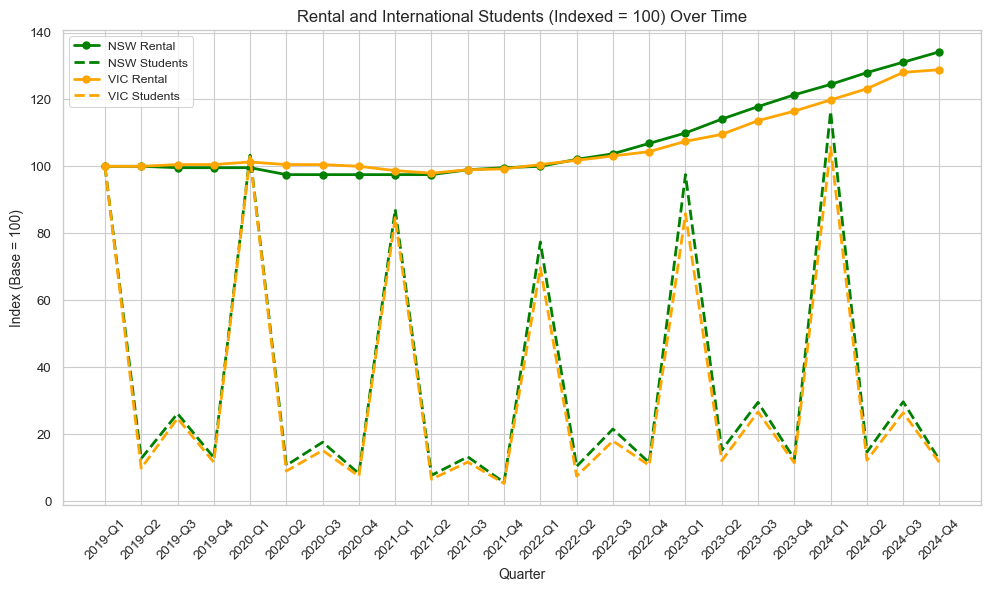

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

plt.figure(figsize=(10, 6))

palette = {"NSW": "green", "VIC": "orange"}

for state in df["State"].unique():
    temp = df[df["State"] == state].copy()
    
    # Normalize both variables (base = first value = 100)
    temp["Rental_norm"] = temp["Rental"] / temp["Rental"].iloc[0] * 100
    temp["Students_norm"] = temp["International Student Enrolments"] / temp["International Student Enrolments"].iloc[0] * 100

    # Plot Rental
    plt.plot(
        temp["Date"].astype(str),
        temp["Rental_norm"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=f"{state} Rental",
        color=palette.get(state)
    )

    # Plot Students (dashed line)
    plt.plot(
        temp["Date"].astype(str),
        temp["Students_norm"],
        linestyle="--",
        linewidth=2,
        label=f"{state} Students",
        color=palette.get(state)
    )

plt.xticks(rotation=45, fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.title("Rental and International Students (Indexed = 100) Over Time", fontsize=12)
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("Index (Base = 100)", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "03_combined_trend.png", dpi=300, bbox_inches="tight")
plt.show()

The graph compares the indexed trends of rental prices and international student enrolments in NSW and VIC from 2019 to 2024, where all series are normalised to a base value of 100 in 2019-Q1. Rental prices in both states remain relatively stable between 2019 and 2021 before increasing steadily from 2022 onwards. The increase becomes particularly pronounced after 2022, with NSW experiencing slightly stronger rental growth than VIC by 2024. In contrast, international student enrolments display substantial volatility and strong seasonal fluctuations across quarters. A sharp decline is visible during 2020–2021, corresponding to the period when Australia imposed international border closures in March 2020 due to COVID-19. Student numbers begin recovering after borders progressively reopened and fully reopened in February 2022, with much stronger increases observed from 2023 onwards. Although both rental prices and student enrolments generally trend upward after 2022, the movements do not appear to align consistently quarter-by-quarter. Rental prices rise relatively smoothly over time, while student enrolments fluctuate sharply due to seasonal intake patterns. This suggests that while international students may contribute to rental demand, enrolment movements alone may not fully explain changes in rental prices.

## 4. Relationship Among Variables

### 4.1 Rental VS International Student 

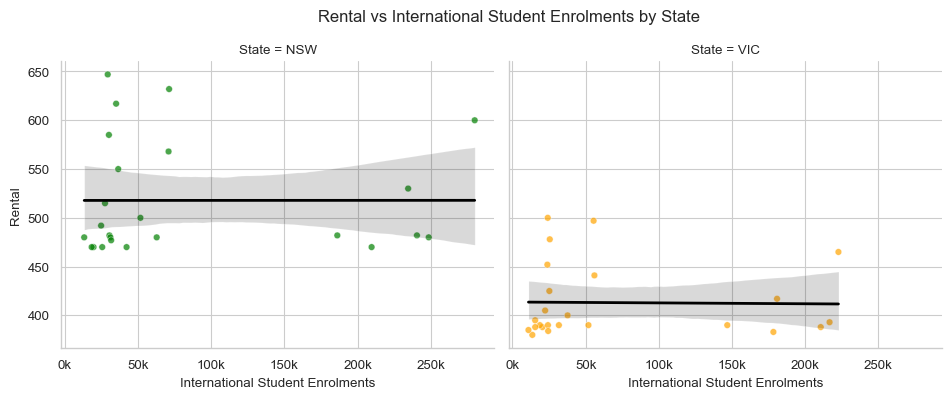

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

g = sns.relplot(
    data=df,
    x="International Student Enrolments",
    y="Rental",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    kind="scatter",
    height=4,
    aspect=1.2,
    alpha=0.7
)

# Add trendline to each state panel
for ax, state in zip(g.axes.flat, sorted(df["State"].unique())):
    sns.regplot(
        data=df[df["State"] == state],
        x="International Student Enrolments",
        y="Rental",
        scatter=False,
        ax=ax,
        color="black",
        line_kws={"linewidth": 2}
    )

g._legend.remove()
g.set_axis_labels("International Student Enrolments", "Rental")

formatter = FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis="both", labelsize=9.5)

g.fig.suptitle("Rental vs International Student Enrolments by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

plt.savefig(output_dir / "04_rental_vs_student.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplots for both New South Wales (NSW) and Victoria (VIC) show little to no clear relationship between international student enrolments and rental prices. In NSW, the fitted line is nearly flat, indicating no strong association between the two variables. The data points are widely dispersed, with rental prices varying across similar levels of student enrolments. This suggests that changes in student numbers are not strongly linked to rental price movements in the short run. In VIC, a similarly weak pattern is observed. While there is a slight positive slope, the relationship appears very weak and not well-defined, with substantial variation in rental prices at different enrolment levels. Overall, the plots suggest that international student enrolments alone do not explain much of the variation in rental prices. The weak relationship may reflect the influence of other factors, such as population growth, housing supply, and broader market conditions.

### 4.2 Rental Changes vs International Student Changes

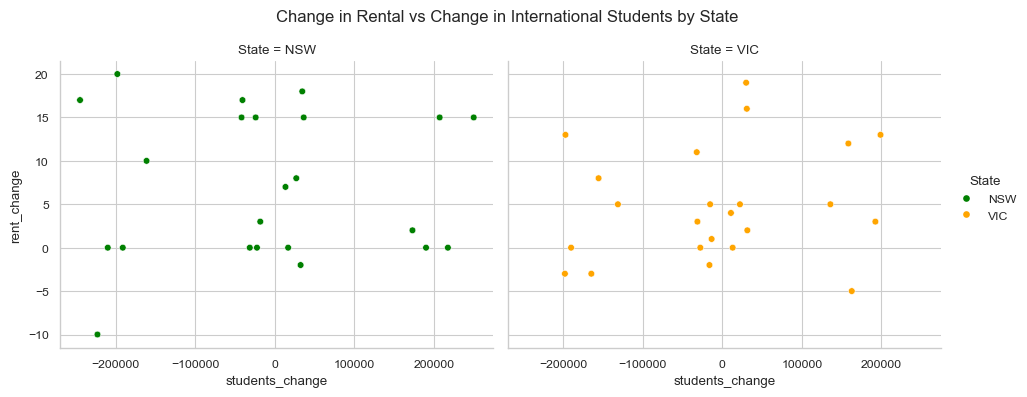

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- OUTPUT FOLDER ---
output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

# --- LOAD DATA ---
df = pd.read_csv("../data/clean/master_dataset.csv")

# --- CREATE CHANGE VARIABLES WITHIN EACH STATE ---
df["rent_change"] = df.groupby("State")["Rental"].diff()
df["students_change"] = df.groupby("State")["International Student Enrolments"].diff()

# --- DROP MISSING VALUES FROM DIFF ---
df = df.dropna(subset=["rent_change", "students_change"])

# --- PLOT: FACETED BY STATE ---
sns.set_style("whitegrid")

g = sns.relplot(
    data=df,
    x="students_change",
    y="rent_change",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
)

g.fig.suptitle("Change in Rental vs Change in International Students by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

# --- SAVE AND SHOW ---
plt.savefig(output_dir / "05_changesrental_vs_changesstudents.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplots show the relationship between changes in international student enrolments and changes in rental prices for NSW and VIC. In both states, the data points are widely dispersed with no clear linear pattern, indicating a weak relationship between the variables. In NSW, changes in student enrolments are associated with both increases and decreases in rental prices, suggesting no consistent direction. Similarly, in VIC, although there are some instances where increases in student numbers coincide with rising rents, the overall pattern remains scattered and inconsistent.

### 4.3 Rental VS Housing Supply 

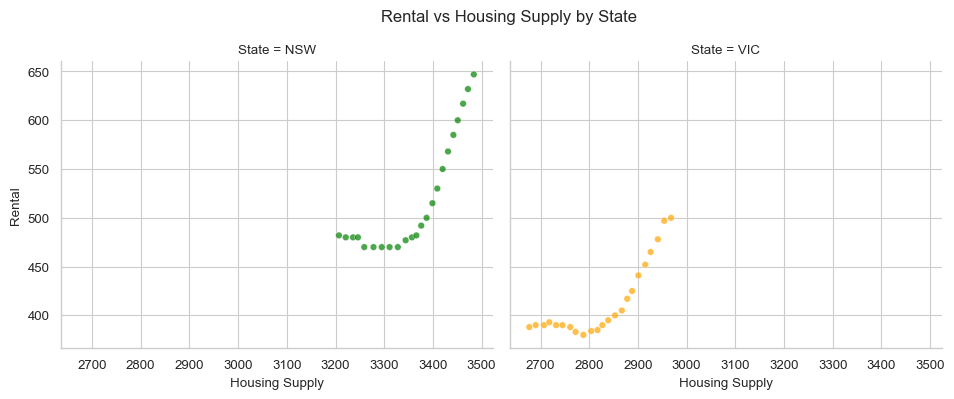

In [15]:
g = sns.relplot(
    data=df,
    x="Housing Supply",
    y="Rental",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
    alpha=0.7
)

g._legend.remove()

for ax in g.axes.flat:
    ax.tick_params(axis="both", labelsize=9.5)

g.fig.suptitle("Rental vs Housing Supply by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

plt.savefig(output_dir / "06_rental_vs_housing.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplots show a positive association between housing supply and rental prices in both NSW and Victoria, with rents increasing as the number of dwellings rises. This contrasts with the standard economic expectation that higher housing supply should place downward pressure on rents. However, this pattern is likely driven by a common upward time trend, as both housing supply (a stock variable) and rental prices increase over the 2019–2024 period. As a result, the observed relationship may reflect shared trends rather than a direct effect. In addition, housing supply is measured at the state level and may mask local housing dynamics. In particular, demand and rental pressures are concentrated in major cities such as Sydney and Melbourne, where both housing development and rent increases are strongest. Demand-side factors such as population growth and international student enrolments may also influence both variables. Therefore, the plot alone does not provide clear evidence on the role of housing supply in explaining rental price changes.

### 4.4 Rental Changes vs Housing Supply Changes 

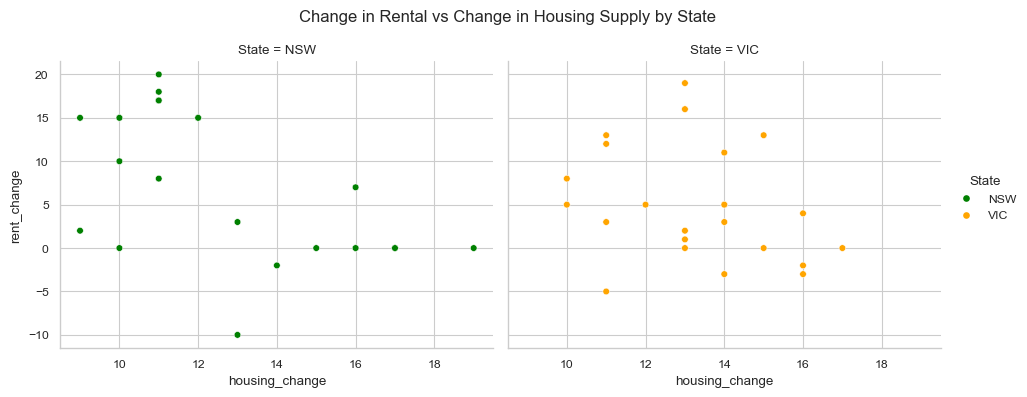

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- OUTPUT FOLDER ---
output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

# --- LOAD DATA ---
df = pd.read_csv("../data/clean/master_dataset.csv")

# --- CREATE CHANGE VARIABLES WITHIN EACH STATE ---
df["rent_change"] = df.groupby("State")["Rental"].diff()
df["housing_change"] = df.groupby("State")["Housing Supply"].diff()

# --- DROP MISSING VALUES FROM DIFF ---
df = df.dropna(subset=["rent_change", "housing_change"])

# --- PLOT: FACETED BY STATE ---
sns.set_style("whitegrid")

g = sns.relplot(
    data=df,
    x="housing_change",
    y="rent_change",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
)

g.fig.suptitle("Change in Rental vs Change in Housing Supply by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

# --- SAVE AND SHOW ---
plt.savefig(output_dir / "07_changesrental_vs_changeshousing_.png", dpi=300, bbox_inches="tight")
plt.show()

The scatter plots show no clear negative relationship between changes in housing supply and changes in rental price changes in either NSW or VIC. Instead, the data points are widely dispersed, with several instances where rental prices increase alongside increases in housing supply, particularly in VIC. This suggests that, at the state level, housing supply alone does not strongly explain short-run rental price movements. One possible explanation is that housing supply is endogenous — new construction may respond to rising demand and higher rents rather than independently driving them. As a result, both housing supply and rental prices may increase simultaneously.
Additionally, the absence of a strong negative relationship may reflect lags in supply adjustment, where new housing takes time to be completed and therefore cannot immediately offset demand pressures. Overall, these patterns indicate that supply-side factors alone may be insufficient to explain rental price changes, highlighting the importance of considering demand-side drivers such as international student enrolments.

### 4.5 Rental VS Population 

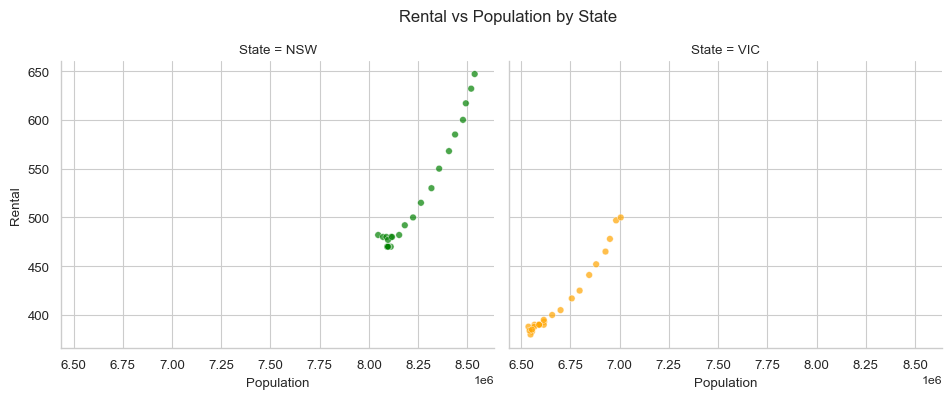

In [17]:
g = sns.relplot(
    data=df,
    x="Population",
    y="Rental",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
    alpha=0.7
)

g._legend.remove()

for ax in g.axes.flat:
    ax.tick_params(axis="both", labelsize=9.5)

g.fig.suptitle("Rental vs Population by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

plt.savefig(output_dir / "08_rental_vs_population.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplots show a strong positive association between population and rental prices in both NSW and Victoria, with higher population levels corresponding to higher rents. This pattern is broadly consistent with economic theory, as population growth increases housing demand and places upward pressure on rents when supply does not expand at the same pace. In the context of 2019–2024, this relationship is plausible, as both states experienced population recovery alongside rising rents following the reopening of international borders and the return of migration and international students. However, the relationship should be interpreted with caution. Since both population and rental prices exhibit upward trends over time, the observed association may partly reflect a shared time trend rather than a true underlying relationship, raising the possibility of spurious correlation. In addition, population is measured at the state level, which may mask important within-state variation in housing demand, particularly in major cities. The relationship may also be influenced by omitted demand-side factors, including international student enrolments and broader economic conditions. Overall, while the plot suggests a strong association between population growth and rental prices, it does not isolate the independent causal effect of population on rents.

### 4.6 Changes in Rental vs Changes in Population

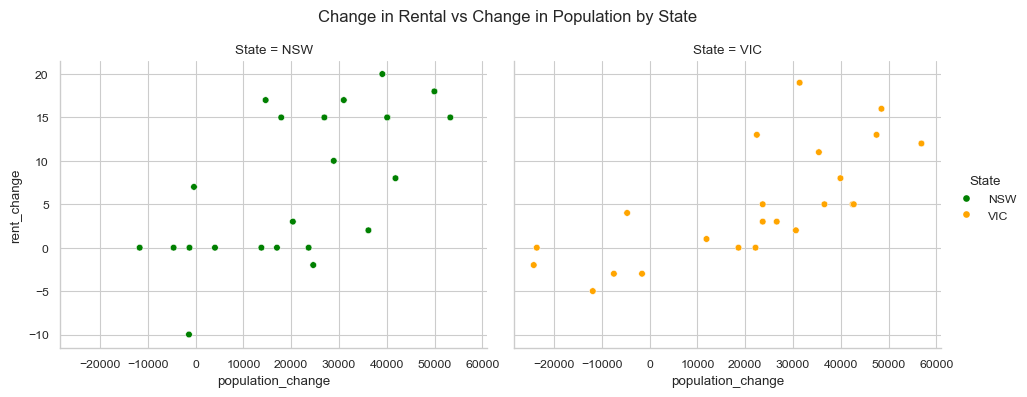

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- OUTPUT FOLDER ---
output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

# --- LOAD DATA ---
df = pd.read_csv("../data/clean/master_dataset.csv")

# --- CREATE CHANGE VARIABLES ---
df["rent_change"] = df.groupby("State")["Rental"].diff()
df["population_change"] = df.groupby("State")["Population"].diff()

# --- DROP MISSING VALUES ---
df = df.dropna(subset=["rent_change", "population_change"])

# --- PLOT (FACET BY STATE) ---
sns.set_style("whitegrid")

g = sns.relplot(
    data=df,
    x="population_change",
    y="rent_change",
    col="State",   # 👈 facet here
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
)

g.fig.suptitle("Change in Rental vs Change in Population by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

# --- SAVE & SHOW ---
plt.savefig(output_dir / "09_changesrental_vs_changespopulation.png", dpi=300, bbox_inches="tight")
plt.show()

There is a general upward trend in NSW and VIC. Higher population growth is associated with higher rental increases. The relationship is clearer and more linear in VIC, while NSW shows more dispersion and less consistent. This may reflect uneven distribution in different housing markets across different areas in NSW leading to variation in how demand translates into rental prices. In contrast, the more linear pattern in VIC indicates a more consistent association between population growth and rental increases. Population change acts as a broader demand proxy, within which international students are a component. With limited short-run housing supply, this demand pressure leads to higher rents. The positive relationship supports including population as a control variable. Failing to control for it would likely cause omitted variable biasthat can overestimate the effect of international students on rental prices. Population growth is an important driver of rental increaseswhich reinforce the demand-side mechanism. However, variation across states indicates that this relationship is not uniform, and must be controlled for rather than assumed.

### 4.7 Seasonally Adjusted International Student Enrolment

/var/folders/0l/n2kg0pt16wlcbzc3h2_1z0g00000gn/T/ipykernel_3320/2875179995.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


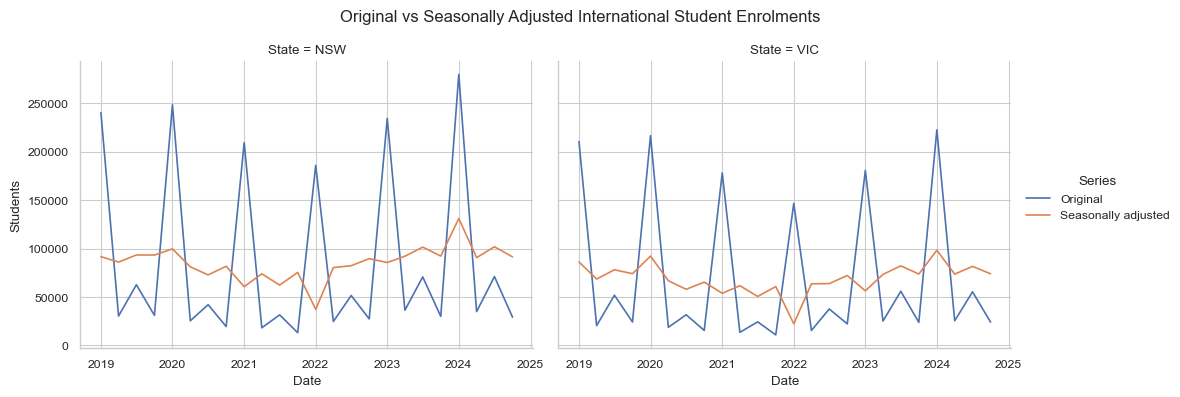

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

# --- OUTPUT FOLDER ---
output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

# --- LOAD DATA ---
df = pd.read_csv("../data/clean/master_dataset.csv")

# --- CLEAN COLUMN NAMES ---
df.columns = df.columns.str.strip()

# --- CONVERT DATE ---
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# --- SORT DATA ---
df = df.sort_values(["State", "Date"]).reset_index(drop=True)

# --- SEASONALLY ADJUST BY STATE SAFELY ---
adjusted_list = []

for state, group in df.groupby("State"):
    group = group.copy()
    group = group.sort_values("Date")

    result = seasonal_decompose(
        group["International Student Enrolments"],
        model="additive",
        period=4,
        extrapolate_trend="freq"
    )

    group["students_seasonally_adjusted"] = (
        group["International Student Enrolments"] - result.seasonal
    )

    group["State"] = state
    adjusted_list.append(group)

df_adjusted = pd.concat(adjusted_list, ignore_index=True)

# --- RESHAPE FOR PLOTTING ---
plot_df = df_adjusted.melt(
    id_vars=["Date", "State"],
    value_vars=[
        "International Student Enrolments",
        "students_seasonally_adjusted"
    ],
    var_name="Series",
    value_name="Students"
)

plot_df["Series"] = plot_df["Series"].replace({
    "International Student Enrolments": "Original",
    "students_seasonally_adjusted": "Seasonally adjusted"
})

# --- PLOT ---
sns.set_style("whitegrid")

g = sns.relplot(
    data=plot_df,
    x="Date",
    y="Students",
    hue="Series",
    col="State",
    kind="line",
    height=4,
    aspect=1.3
)

g.fig.suptitle(
    "Original vs Seasonally Adjusted International Student Enrolments",
    fontsize=12
)

g.fig.subplots_adjust(top=0.85)

plt.savefig(
    output_dir / "10_students_original_vs_seasonally_adjusted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The graphs show international student enrolments for NSW and VIC over time, comparing the original series with the seasonally adjusted series. In both states, the original data exhibits strong seasonal spikes, with very large peaks occurring at regular intervals each year. These spikes likely reflect major student intake periods, rather than true underlying changes in demand. In contrast, the seasonally adjusted series is much smoother, removing these recurring patterns and providing a clearer view of the underlying trend. A noticeable decline in enrolments occurs around 2020–2021, which aligns with the period when Australia closed its international borders in March 2020 due to COVID-19. Enrolments remain relatively subdued during this period. From early 2022 onwards, when borders were progressively reopened (fully reopening in February 2022), enrolments begin to recover, with a clearer upward trend visible in the adjusted series.